# Oversizing Analysis for Stand-Alone PV and Wind Plants

This notebook:
1. Loads and cleans raw data (PV, Wind, Prices)
2. Creates an aligned hourly dataset
3. Runs NPV analysis for different oversizing factors
4. Identifies optimal oversizing for each technology


In [1]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from preprocess import build_clean_dataset, save_clean_dataset

# Set display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(f"Project root: {project_root}")


Project root: /Users/fynnfroehlich/Master Thesis


## 1. Load and Clean Raw Data


In [2]:
# Build cleaned dataset using shared preprocessing
df = build_clean_dataset(
    wind_path=project_root / 'data_raw' / 'wind_data.csv',
    pv_path=project_root / 'data_raw' / 'pv_data.csv',
    price_path=project_root / 'data_raw' / 'price_data.csv',
)

print(f'Final dataset shape: {df.shape}')
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print('\nMissing values:')
print(df.isna().sum())



# Summary statistics
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"\nTotal hours: {len(df)}")
print(f"\nPrice statistics (EUR/MWh):")
print(df["price_eur_per_mwh"].describe())
print(f"\nNegative price hours: {(df['price_eur_per_mwh'] < 0).sum()}")
print(f"\nPV capacity factor statistics (per 1 kW):")
print(df["pv_per_kw"].describe())
print(f"\nWind capacity factor statistics (per 1 kW):")
print(df["wind_per_kw"].describe())

df.head()



Final dataset shape: (8760, 4)
Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00

Missing values:
timestamp            0
price_eur_per_mwh    0
pv_per_kw            0
wind_per_kw          0
dtype: int64
DATASET SUMMARY

Total hours: 8760

Price statistics (EUR/MWh):
count   8,760.00
mean       78.55
std        52.79
min      -135.45
25%        55.61
50%        79.70
75%       101.39
max       936.28
Name: price_eur_per_mwh, dtype: float64

Negative price hours: 457

PV capacity factor statistics (per 1 kW):
count   8,760.00
mean        0.13
std         0.21
min         0.00
25%         0.00
50%         0.00
75%         0.19
max         0.81
Name: pv_per_kw, dtype: float64

Wind capacity factor statistics (per 1 kW):
count   8,760.00
mean        0.27
std         0.20
min         0.00
25%         0.11
50%         0.23
75%         0.37
max         0.97
Name: wind_per_kw, dtype: float64


,timestamp,price_eur_per_mwh,pv_per_kw,wind_per_kw
0,2024-01-01 00:00:00,0.10,0.00,0.27
1,2024-01-01 01:00:00,0.01,0.00,0.24
2,2024-01-01 02:00:00,0.00,0.00,0.24
3,2024-01-01 03:00:00,-0.01,0.00,0.24
4,2024-01-01 04:00:00,-0.03,0.00,0.25


In [3]:
# Save cleaned dataset
output_path = project_root / 'data_processed' / 'hourly_data.csv'
save_clean_dataset(df, output_path)


Saved cleaned dataset to /Users/fynnfroehlich/Master Thesis/data_processed/hourly_data.csv


## 3. Run Oversizing Analysis


In [4]:
# Import analysis functions
from oversizing_analysis import (
    evaluate_oversizing_grid,
    find_optimal_alpha,
    results_to_dataframe,
)
from config import (
    POI_CAPACITY_MW,
    CAPEX_PV_EUR_PER_KW,
    OPEX_PV_EUR_PER_KW_PER_YEAR,
    LIFETIME_PV_YEARS,
    WACC_PV_REAL,
    DEGRADATION_PV_PER_YEAR,
    CAPEX_WIND_EUR_PER_KW,
    OPEX_WIND_EUR_PER_KW_PER_YEAR,
    LIFETIME_WIND_YEARS,
    WACC_WIND_REAL,
)

print("=" * 60)
print("TECHNO-ECONOMIC PARAMETERS")
print("=" * 60)
print(f"\nPOI Capacity: {POI_CAPACITY_MW} MW")
print(f"\nPV Parameters:")
print(f"  CAPEX: €{CAPEX_PV_EUR_PER_KW}/kW")
print(f"  OPEX: €{OPEX_PV_EUR_PER_KW_PER_YEAR}/kW/year")
print(f"  Lifetime: {LIFETIME_PV_YEARS} years")
print(f"  WACC: {WACC_PV_REAL*100:.1f}%")
print(f"  Degradation: {DEGRADATION_PV_PER_YEAR*100:.2f}%/year")
print(f"\nWind Parameters:")
print(f"  CAPEX: €{CAPEX_WIND_EUR_PER_KW}/kW")
print(f"  OPEX: €{OPEX_WIND_EUR_PER_KW_PER_YEAR}/kW/year")
print(f"  Lifetime: {LIFETIME_WIND_YEARS} years")
print(f"  WACC: {WACC_WIND_REAL*100:.1f}%")


TECHNO-ECONOMIC PARAMETERS

POI Capacity: 10.0 MW

PV Parameters:
  CAPEX: €700.0/kW
  OPEX: €13.3/kW/year
  Lifetime: 30 years
  WACC: 3.5%
  Degradation: 0.25%/year

Wind Parameters:
  CAPEX: €1300.0/kW
  OPEX: €32.0/kW/year
  Lifetime: 25 years
  WACC: 3.9%


In [5]:
# Define oversizing factors to evaluate - fine grid with 0.1 steps
alphas = [round(x, 2) for x in np.arange(1.0, 3.01, 0.1)]

print(f"Evaluating {len(alphas)} oversizing factors from {alphas[0]} to {alphas[-1]}")


Evaluating 21 oversizing factors from 1.0 to 3.0


### 3.1 PV Oversizing Analysis


In [6]:
# Evaluate PV oversizing
pv_results = evaluate_oversizing_grid(df, tech="pv", alphas=alphas)
pv_optimal = find_optimal_alpha(pv_results)

df_pv = results_to_dataframe(pv_results)

# Add derived metrics
df_pv["total_generation_mwh"] = df_pv["annual_export_mwh"] + df_pv["annual_curtailment_mwh"]
df_pv["curtailment_pct"] = df_pv["annual_curtailment_mwh"] / df_pv["total_generation_mwh"] * 100
df_pv["capacity_factor_pct"] = df_pv["total_generation_mwh"] / (df_pv["capacity_mw"] * 8760) * 100
df_pv["export_factor_pct"] = df_pv["annual_export_mwh"] / (df_pv["capacity_mw"] * 8760) * 100

print("=" * 80)
print("PV OVERSIZING RESULTS")
print("=" * 80)
print(df_pv.to_string(index=False))


PV OVERSIZING RESULTS
tech  alpha  capacity_mw       npv_eur  irr  annual_revenue_eur  annual_export_mwh  annual_curtailment_mwh  export_per_mw_poi_mwh  poi_utilisation_factor  capex_total_eur  annual_opex_total_eur  wacc  lifetime_years  total_generation_mwh  curtailment_pct  capacity_factor_pct  export_factor_pct
  pv   1.00        10.00  1,763,833.88 0.05          627,896.29           9,756.21                1,828.63                 975.62                    0.11     7,000,000.00             133,000.00  0.04              30             11,584.84            15.78                13.22              11.14
  pv   1.10        11.00  1,940,217.27 0.05          690,685.92          10,731.83                2,011.49               1,073.18                    0.12     7,700,000.00             146,300.00  0.04              30             12,743.32            15.78                13.22              11.14
  pv   1.20        12.00  2,116,600.66 0.05          753,475.55          11,707.45           

In [7]:
print(f"\n{'='*60}")
print("OPTIMAL PV CONFIGURATION")
print(f"{'='*60}")
print(f"Optimal oversizing factor α: {pv_optimal.alpha:.2f}")
print(f"Installed capacity: {pv_optimal.capacity_mw:.1f} MW")
print(f"NPV: €{pv_optimal.npv_eur:,.0f}")
print(f"Annual revenue (Year 1): €{pv_optimal.annual_revenue_eur:,.0f}")
print(f"Annual export: {pv_optimal.annual_export_mwh:,.0f} MWh")
print(f"Annual curtailment: {pv_optimal.annual_curtailment_mwh:,.0f} MWh")



OPTIMAL PV CONFIGURATION
Optimal oversizing factor α: 1.60
Installed capacity: 16.0 MW
NPV: €2,540,303
Annual revenue (Year 1): €988,848
Annual export: 15,236 MWh
Annual curtailment: 3,300 MWh


### 3.2 Wind Oversizing Analysis


In [8]:
# Evaluate Wind oversizing
wind_results = evaluate_oversizing_grid(df, tech="wind", alphas=alphas)
wind_optimal = find_optimal_alpha(wind_results)

df_wind = results_to_dataframe(wind_results)

# Add derived metrics
df_wind["total_generation_mwh"] = df_wind["annual_export_mwh"] + df_wind["annual_curtailment_mwh"]
df_wind["curtailment_pct"] = df_wind["annual_curtailment_mwh"] / df_wind["total_generation_mwh"] * 100
df_wind["capacity_factor_pct"] = df_wind["total_generation_mwh"] / (df_wind["capacity_mw"] * 8760) * 100
df_wind["export_factor_pct"] = df_wind["annual_export_mwh"] / (df_wind["capacity_mw"] * 8760) * 100

print("=" * 80)
print("WIND OVERSIZING RESULTS")
print("=" * 80)
print(df_wind.to_string(index=False))


WIND OVERSIZING RESULTS
tech  alpha  capacity_mw       npv_eur  irr  annual_revenue_eur  annual_export_mwh  annual_curtailment_mwh  export_per_mw_poi_mwh  poi_utilisation_factor  capex_total_eur  annual_opex_total_eur  wacc  lifetime_years  total_generation_mwh  curtailment_pct  capacity_factor_pct  export_factor_pct
wind   1.00        10.00  6,941,393.06 0.08        1,583,031.20          21,771.77                1,692.97               2,177.18                    0.25    13,000,000.00             320,000.00  0.04              25             23,464.74             7.21                26.79              24.85
wind   1.10        11.00  7,623,855.33 0.08        1,740,594.73          23,933.42                1,877.79               2,393.34                    0.27    14,300,000.00             352,000.00  0.04              25             25,811.21             7.28                26.79              24.84
wind   1.20        12.00  8,257,203.86 0.08        1,895,047.54          26,030.01         

In [9]:
print(f"\n{'='*60}")
print("OPTIMAL WIND CONFIGURATION")
print(f"{'='*60}")
print(f"Optimal oversizing factor α: {wind_optimal.alpha:.2f}")
print(f"Installed capacity: {wind_optimal.capacity_mw:.1f} MW")
print(f"NPV: €{wind_optimal.npv_eur:,.0f}")
print(f"Annual revenue (Year 1): €{wind_optimal.annual_revenue_eur:,.0f}")
print(f"Annual export: {wind_optimal.annual_export_mwh:,.0f} MWh")
print(f"Annual curtailment: {wind_optimal.annual_curtailment_mwh:,.0f} MWh")



OPTIMAL WIND CONFIGURATION
Optimal oversizing factor α: 2.10
Installed capacity: 21.0 MW
NPV: €11,168,145
Annual revenue (Year 1): €3,108,463
Annual export: 41,643 MWh
Annual curtailment: 7,633 MWh


## 4. Visualization


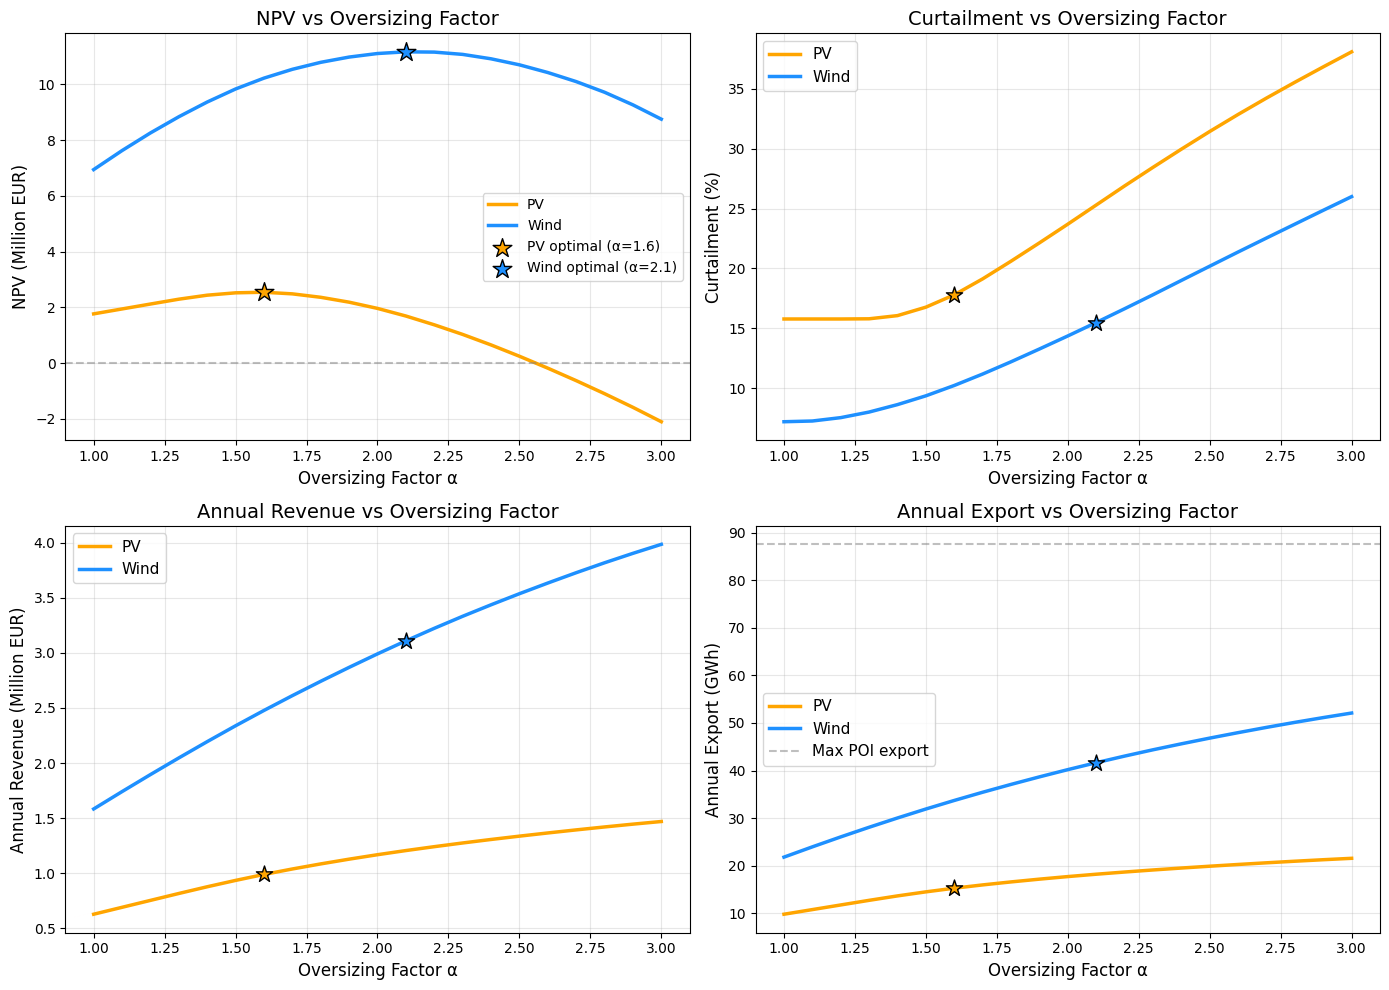

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color scheme
pv_color = "#FFA500"  # Orange
wind_color = "#1E90FF"  # Blue

# Plot 1: NPV vs Alpha
ax1 = axes[0, 0]
ax1.plot(df_pv["alpha"], df_pv["npv_eur"] / 1e6, "-", label="PV", color=pv_color, linewidth=2.5)
ax1.plot(df_wind["alpha"], df_wind["npv_eur"] / 1e6, "-", label="Wind", color=wind_color, linewidth=2.5)
ax1.scatter([pv_optimal.alpha], [pv_optimal.npv_eur / 1e6], color=pv_color, s=200, marker="*", edgecolors="black", zorder=5, label=f"PV optimal (α={pv_optimal.alpha:.1f})")
ax1.scatter([wind_optimal.alpha], [wind_optimal.npv_eur / 1e6], color=wind_color, s=200, marker="*", edgecolors="black", zorder=5, label=f"Wind optimal (α={wind_optimal.alpha:.1f})")
ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("Oversizing Factor α", fontsize=12)
ax1.set_ylabel("NPV (Million EUR)", fontsize=12)
ax1.set_title("NPV vs Oversizing Factor", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Curtailment vs Alpha
ax2 = axes[0, 1]
ax2.plot(df_pv["alpha"], df_pv["curtailment_pct"], "-", label="PV", color=pv_color, linewidth=2.5)
ax2.plot(df_wind["alpha"], df_wind["curtailment_pct"], "-", label="Wind", color=wind_color, linewidth=2.5)
ax2.scatter([pv_optimal.alpha], [df_pv.loc[df_pv["alpha"] == pv_optimal.alpha, "curtailment_pct"].values[0]], color=pv_color, s=150, marker="*", edgecolors="black", zorder=5)
ax2.scatter([wind_optimal.alpha], [df_wind.loc[df_wind["alpha"] == wind_optimal.alpha, "curtailment_pct"].values[0]], color=wind_color, s=150, marker="*", edgecolors="black", zorder=5)
ax2.set_xlabel("Oversizing Factor α", fontsize=12)
ax2.set_ylabel("Curtailment (%)", fontsize=12)
ax2.set_title("Curtailment vs Oversizing Factor", fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Annual Revenue vs Alpha
ax3 = axes[1, 0]
ax3.plot(df_pv["alpha"], df_pv["annual_revenue_eur"] / 1e6, "-", label="PV", color=pv_color, linewidth=2.5)
ax3.plot(df_wind["alpha"], df_wind["annual_revenue_eur"] / 1e6, "-", label="Wind", color=wind_color, linewidth=2.5)
ax3.scatter([pv_optimal.alpha], [pv_optimal.annual_revenue_eur / 1e6], color=pv_color, s=150, marker="*", edgecolors="black", zorder=5)
ax3.scatter([wind_optimal.alpha], [wind_optimal.annual_revenue_eur / 1e6], color=wind_color, s=150, marker="*", edgecolors="black", zorder=5)
ax3.set_xlabel("Oversizing Factor α", fontsize=12)
ax3.set_ylabel("Annual Revenue (Million EUR)", fontsize=12)
ax3.set_title("Annual Revenue vs Oversizing Factor", fontsize=14)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Plot 4: Annual Export vs Alpha
ax4 = axes[1, 1]
ax4.plot(df_pv["alpha"], df_pv["annual_export_mwh"] / 1e3, "-", label="PV", color=pv_color, linewidth=2.5)
ax4.plot(df_wind["alpha"], df_wind["annual_export_mwh"] / 1e3, "-", label="Wind", color=wind_color, linewidth=2.5)
ax4.scatter([pv_optimal.alpha], [pv_optimal.annual_export_mwh / 1e3], color=pv_color, s=150, marker="*", edgecolors="black", zorder=5)
ax4.scatter([wind_optimal.alpha], [wind_optimal.annual_export_mwh / 1e3], color=wind_color, s=150, marker="*", edgecolors="black", zorder=5)
ax4.axhline(y=POI_CAPACITY_MW * 8760 / 1e3, color="gray", linestyle="--", alpha=0.5, label="Max POI export")
ax4.set_xlabel("Oversizing Factor α", fontsize=12)
ax4.set_ylabel("Annual Export (GWh)", fontsize=12)
ax4.set_title("Annual Export vs Oversizing Factor", fontsize=14)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "figures" / "npv_oversizing_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Summary Table


In [11]:
# Create comparison summary
summary = pd.DataFrame({
    "Metric": [
        "Optimal α",
        "Installed Capacity (MW)",
        "NPV (€)",
        "Annual Revenue Year 1 (€)",
        "Annual Export (MWh)",
        "Annual Curtailment (MWh)",
        "Curtailment (%)",
    ],
    "PV": [
        f"{pv_optimal.alpha:.2f}",
        f"{pv_optimal.capacity_mw:.1f}",
        f"{pv_optimal.npv_eur:,.0f}",
        f"{pv_optimal.annual_revenue_eur:,.0f}",
        f"{pv_optimal.annual_export_mwh:,.0f}",
        f"{pv_optimal.annual_curtailment_mwh:,.0f}",
        f"{pv_optimal.annual_curtailment_mwh / (pv_optimal.annual_export_mwh + pv_optimal.annual_curtailment_mwh) * 100:.1f}%",
    ],
    "Wind": [
        f"{wind_optimal.alpha:.2f}",
        f"{wind_optimal.capacity_mw:.1f}",
        f"{wind_optimal.npv_eur:,.0f}",
        f"{wind_optimal.annual_revenue_eur:,.0f}",
        f"{wind_optimal.annual_export_mwh:,.0f}",
        f"{wind_optimal.annual_curtailment_mwh:,.0f}",
        f"{wind_optimal.annual_curtailment_mwh / (wind_optimal.annual_export_mwh + wind_optimal.annual_curtailment_mwh) * 100:.1f}%",
    ],
})

print("=" * 60)
print("OPTIMAL CONFIGURATION COMPARISON")
print("=" * 60)
print(summary.to_string(index=False))


OPTIMAL CONFIGURATION COMPARISON
                   Metric        PV       Wind
                Optimal α      1.60       2.10
  Installed Capacity (MW)      16.0       21.0
                  NPV (€) 2,540,303 11,168,145
Annual Revenue Year 1 (€)   988,848  3,108,463
      Annual Export (MWh)    15,236     41,643
 Annual Curtailment (MWh)     3,300      7,633
          Curtailment (%)     17.8%      15.5%


In [12]:
# Save results to CSV
df_pv.to_csv(project_root / "data_processed" / "pv_oversizing_results.csv", index=False)
df_wind.to_csv(project_root / "data_processed" / "wind_oversizing_results.csv", index=False)
print("Results saved to data_processed/")


Results saved to data_processed/


---

## 6. Hybrid PV + Wind Analysis

Now we analyze co-located PV and wind plants sharing the same 10 MW POI.


In [13]:
# Force reload of updated modules (needed after code changes)
import importlib
import economics
import hybrid_analysis
importlib.reload(economics)
importlib.reload(hybrid_analysis)

from hybrid_analysis import (
    evaluate_hybrid_grid,
    find_best_hybrid_by_npv,
    results_to_dataframe as hybrid_results_to_dataframe,
    pivot_npv_heatmap,
)
from config import LIFETIME_PV_YEARS, LIFETIME_WIND_YEARS

print(f"PV lifetime: {LIFETIME_PV_YEARS} years, Wind lifetime: {LIFETIME_WIND_YEARS} years")
print("(Hybrid cash flows extend to max lifetime, each tech contributes only during its lifetime)")


PV lifetime: 30 years, Wind lifetime: 25 years
(Hybrid cash flows extend to max lifetime, each tech contributes only during its lifetime)


In [14]:
# Quick statistics
print("Price Statistics (EUR/MWh):")
print(f"  Mean: {df['price_eur_per_mwh'].mean():.2f}")
print(f"  Median: {df['price_eur_per_mwh'].median():.2f}")
print(f"  Min: {df['price_eur_per_mwh'].min():.2f}")
print(f"  Max: {df['price_eur_per_mwh'].max():.2f}")
print(f"  Negative price hours: {(df['price_eur_per_mwh'] < 0).sum()} ({100*(df['price_eur_per_mwh'] < 0).mean():.1f}%)")

print("\nPV Capacity Factor Statistics:")
print(f"  Mean: {df['pv_per_kw'].mean():.4f}")
print(f"  Max: {df['pv_per_kw'].max():.4f}")


Price Statistics (EUR/MWh):
  Mean: 78.55
  Median: 79.70
  Min: -135.45
  Max: 936.28
  Negative price hours: 457 (5.2%)

PV Capacity Factor Statistics:
  Mean: 0.1322
  Max: 0.8110


In [15]:
# Quick statistics
print("Price Statistics (EUR/MWh):")
print(f"  Mean: {df['price_eur_per_mwh'].mean():.2f}")
print(f"  Median: {df['price_eur_per_mwh'].median():.2f}")
print(f"  Min: {df['price_eur_per_mwh'].min():.2f}")
print(f"  Max: {df['price_eur_per_mwh'].max():.2f}")
print(f"  Negative price hours: {(df['price_eur_per_mwh'] < 0).sum()} ({100*(df['price_eur_per_mwh'] < 0).mean():.1f}%)")

print("\nPV Capacity Factor Statistics:")
print(f"  Mean: {df['pv_per_kw'].mean():.4f}")
print(f"  Max: {df['pv_per_kw'].max():.4f}")


Price Statistics (EUR/MWh):
  Mean: 78.55
  Median: 79.70
  Min: -135.45
  Max: 936.28
  Negative price hours: 457 (5.2%)

PV Capacity Factor Statistics:
  Mean: 0.1322
  Max: 0.8110


In [16]:
# Quick statistics
print("Price Statistics (EUR/MWh):")
print(f"  Mean: {df['price_eur_per_mwh'].mean():.2f}")
print(f"  Median: {df['price_eur_per_mwh'].median():.2f}")
print(f"  Min: {df['price_eur_per_mwh'].min():.2f}")
print(f"  Max: {df['price_eur_per_mwh'].max():.2f}")
print(f"  Negative price hours: {(df['price_eur_per_mwh'] < 0).sum()} ({100*(df['price_eur_per_mwh'] < 0).mean():.1f}%)")

print("\nPV Capacity Factor Statistics:")
print(f"  Mean: {df['pv_per_kw'].mean():.4f}")
print(f"  Max: {df['pv_per_kw'].max():.4f}")


Price Statistics (EUR/MWh):
  Mean: 78.55
  Median: 79.70
  Min: -135.45
  Max: 936.28
  Negative price hours: 457 (5.2%)

PV Capacity Factor Statistics:
  Mean: 0.1322
  Max: 0.8110


In [17]:
# Quick statistics
print("Price Statistics (EUR/MWh):")
print(f"  Mean: {df['price_eur_per_mwh'].mean():.2f}")
print(f"  Median: {df['price_eur_per_mwh'].median():.2f}")
print(f"  Min: {df['price_eur_per_mwh'].min():.2f}")
print(f"  Max: {df['price_eur_per_mwh'].max():.2f}")
print(f"  Negative price hours: {(df['price_eur_per_mwh'] < 0).sum()} ({100*(df['price_eur_per_mwh'] < 0).mean():.1f}%)")

print("\nPV Capacity Factor Statistics:")
print(f"  Mean: {df['pv_per_kw'].mean():.4f}")
print(f"  Max: {df['pv_per_kw'].max():.4f}")


Price Statistics (EUR/MWh):
  Mean: 78.55
  Median: 79.70
  Min: -135.45
  Max: 936.28
  Negative price hours: 457 (5.2%)

PV Capacity Factor Statistics:
  Mean: 0.1322
  Max: 0.8110


In [18]:
# Define grids for hybrid analysis - high resolution
# Total overplanting: 1.0 to 3.0 in 0.05 steps (41 values)
# Wind share: 0% to 100% in 2% steps (51 values)
alpha_tot_values = [round(x, 2) for x in np.arange(1.0, 3.01, 0.05)]
s_wind_values = [round(x, 2) for x in np.arange(0.0, 1.01, 0.02)]

print(f"Total overplanting factors: {len(alpha_tot_values)} values from {alpha_tot_values[0]} to {alpha_tot_values[-1]}")
print(f"Wind share values: {len(s_wind_values)} values from {s_wind_values[0]:.0%} to {s_wind_values[-1]:.0%}")
print(f"Total combinations to evaluate: {len(alpha_tot_values) * len(s_wind_values)}")


Total overplanting factors: 41 values from 1.0 to 3.0
Wind share values: 51 values from 0% to 100%
Total combinations to evaluate: 2091


In [19]:
%%time
# Evaluate all hybrid combinations
hybrid_results = evaluate_hybrid_grid(df, alpha_tot_values, s_wind_values)
print(f"Evaluated {len(hybrid_results)} hybrid configurations")


Evaluated 2091 hybrid configurations
CPU times: user 591 ms, sys: 13.7 ms, total: 604 ms
Wall time: 605 ms


In [20]:
# Find optimal hybrid configuration
best_hybrid = find_best_hybrid_by_npv(hybrid_results)

print("=" * 70)
print("OPTIMAL HYBRID CONFIGURATION")
print("=" * 70)
print(f"Total overplanting factor (α_tot): {best_hybrid.alpha_tot:.1f}")
print(f"Wind share (s_wind): {best_hybrid.s_wind:.0%}")
print(f"PV capacity: {best_hybrid.pv_capacity_mw:.1f} MW")
print(f"Wind capacity: {best_hybrid.wind_capacity_mw:.1f} MW")
print(f"Total capacity: {best_hybrid.pv_capacity_mw + best_hybrid.wind_capacity_mw:.1f} MW")
print(f"WACC (CAPEX-weighted): {best_hybrid.wacc*100:.2f}%")
print(f"\nNPV: €{best_hybrid.npv_eur:,.0f}")
print(f"\nAnnual Revenue (Year 1):")
print(f"  Total: €{best_hybrid.annual_revenue_eur_total:,.0f}")
print(f"  PV: €{best_hybrid.annual_revenue_eur_pv:,.0f}")
print(f"  Wind: €{best_hybrid.annual_revenue_eur_wind:,.0f}")
print(f"\nAnnual Export:")
print(f"  Total: {best_hybrid.annual_export_mwh_total:,.0f} MWh")
print(f"  PV: {best_hybrid.annual_export_mwh_pv:,.0f} MWh")
print(f"  Wind: {best_hybrid.annual_export_mwh_wind:,.0f} MWh")
print(f"\nAnnual Curtailment:")
print(f"  Total: {best_hybrid.annual_curtailment_mwh_total:,.0f} MWh")
print(f"  PV: {best_hybrid.annual_curtailment_mwh_pv:,.0f} MWh")
print(f"  Wind: {best_hybrid.annual_curtailment_mwh_wind:,.0f} MWh")


OPTIMAL HYBRID CONFIGURATION
Total overplanting factor (α_tot): 2.7
Wind share (s_wind): 74%
PV capacity: 7.0 MW
Wind capacity: 20.0 MW
Total capacity: 27.0 MW
WACC (CAPEX-weighted): 3.84%

NPV: €11,615,082

Annual Revenue (Year 1):
  Total: €3,383,627
  PV: €426,288
  Wind: €2,957,339

Annual Export:
  Total: 45,985 MWh
  PV: 6,503 MWh
  Wind: 39,482 MWh

Annual Curtailment:
  Total: 9,030 MWh
  PV: 1,630 MWh
  Wind: 7,401 MWh


In [21]:
# Convert to DataFrame
df_hybrid = hybrid_results_to_dataframe(hybrid_results)

# Add derived metrics
df_hybrid["total_capacity_mw"] = df_hybrid["pv_capacity_mw"] + df_hybrid["wind_capacity_mw"]
df_hybrid["curtailment_pct"] = (
    df_hybrid["annual_curtailment_mwh_total"] / 
    (df_hybrid["annual_export_mwh_total"] + df_hybrid["annual_curtailment_mwh_total"]) * 100
)

print(f"Hybrid results DataFrame shape: {df_hybrid.shape}")
df_hybrid.head(10)


Hybrid results DataFrame shape: (2091, 26)


,alpha_tot,s_wind,pv_capacity_mw,wind_capacity_mw,wacc,npv_eur,irr,annual_revenue_eur_total,annual_revenue_eur_pv,annual_revenue_eur_wind,...,export_per_mw_poi_mwh,poi_utilisation_factor,capex_pv_eur,capex_wind_eur,capex_total_eur,annual_opex_pv_eur,annual_opex_wind_eur,annual_opex_total_eur,total_capacity_mw,curtailment_pct
0,1.00,0.00,10.00,0.00,0.04,"1,763,833.88",0.05,"627,896.29","627,896.29",0.00,...,975.62,0.11,"7,000,000.00",0.00,"7,000,000.00","133,000.00",0.00,"133,000.00",10.00,15.78
1,1.00,0.02,9.80,0.20,0.04,"1,868,809.48",0.06,"646,998.99","615,338.37","31,660.62",...,999.65,0.11,"6,860,000.00","260,000.00","7,120,000.00","130,340.00","6,400.00","136,740.00",10.00,15.44
2,1.00,0.04,9.60,0.40,0.04,"1,973,682.51",0.06,"666,101.69","602,780.44","63,321.25",...,"1,023.68",0.12,"6,720,000.00","520,000.00","7,240,000.00","127,680.00","12,800.00","140,480.00",10.00,15.12
3,1.00,0.06,9.40,0.60,0.04,"2,078,457.78",0.06,"685,204.39","590,222.52","94,981.87",...,"1,047.71",0.12,"6,580,000.00","780,000.00","7,360,000.00","125,020.00","19,200.00","144,220.00",10.00,14.80
4,1.00,0.08,9.20,0.80,0.04,"2,183,139.79",0.06,"704,307.09","577,664.59","126,642.50",...,"1,071.75",0.12,"6,440,000.00","1,040,000.00","7,480,000.00","122,360.00","25,600.00","147,960.00",10.00,14.50
5,1.00,0.10,9.00,1.00,0.04,"2,287,732.79",0.06,"723,409.79","565,106.66","158,303.12",...,"1,095.78",0.13,"6,300,000.00","1,300,000.00","7,600,000.00","119,700.00","32,000.00","151,700.00",10.00,14.21
6,1.00,0.12,8.80,1.20,0.04,"2,392,240.75",0.06,"742,512.48","552,548.74","189,963.74",...,"1,119.81",0.13,"6,160,000.00","1,560,000.00","7,720,000.00","117,040.00","38,400.00","155,440.00",10.00,13.93
7,1.00,0.14,8.60,1.40,0.04,"2,496,667.43",0.06,"761,615.18","539,990.81","221,624.37",...,"1,143.84",0.13,"6,020,000.00","1,820,000.00","7,840,000.00","114,380.00","44,800.00","159,180.00",10.00,13.66
8,1.00,0.16,8.40,1.60,0.04,"2,601,016.38",0.06,"780,717.88","527,432.89","253,284.99",...,"1,167.87",0.13,"5,880,000.00","2,080,000.00","7,960,000.00","111,720.00","51,200.00","162,920.00",10.00,13.40
9,1.00,0.18,8.20,1.80,0.04,"2,705,290.92",0.06,"799,820.58","514,874.96","284,945.62",...,"1,191.90",0.14,"5,740,000.00","2,340,000.00","8,080,000.00","109,060.00","57,600.00","166,660.00",10.00,13.15


### 6.1 NPV Heatmap


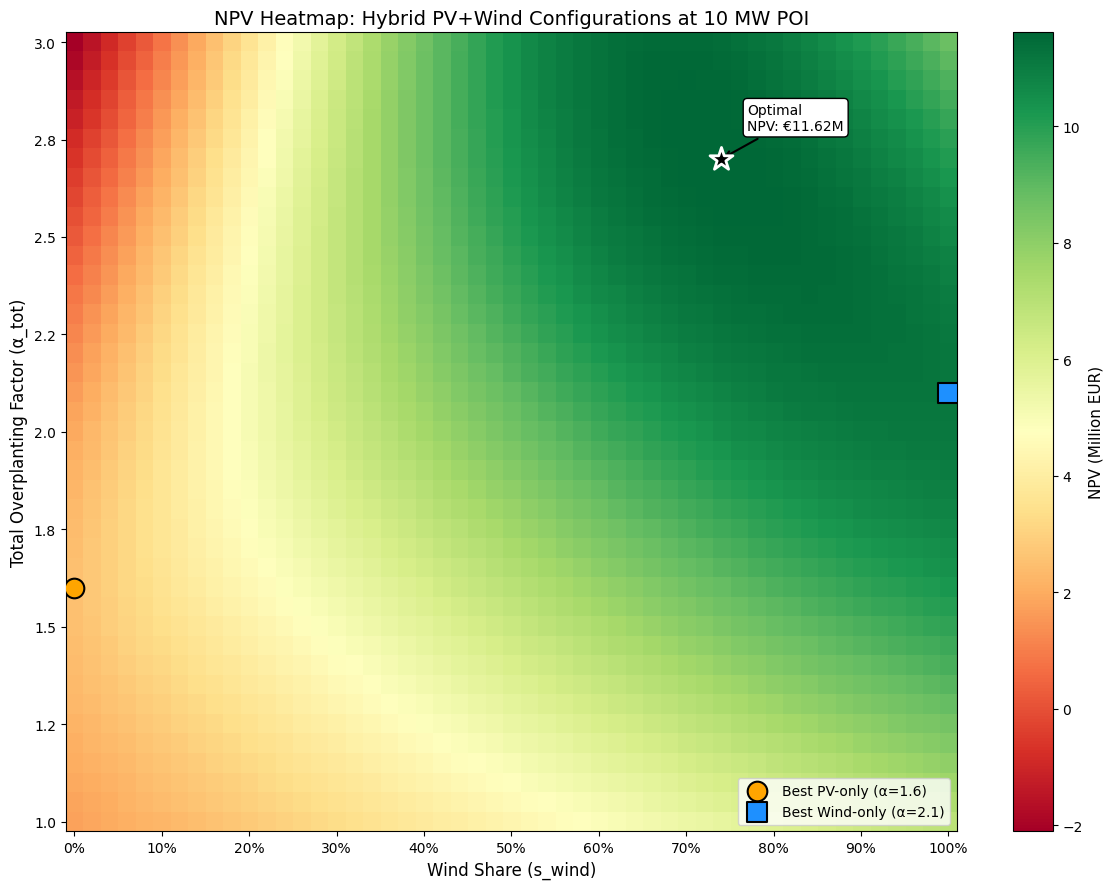

In [22]:
# Create NPV heatmap
npv_matrix = pivot_npv_heatmap(df_hybrid)

fig, ax = plt.subplots(figsize=(12, 9))

# Plot heatmap
im = ax.imshow(
    npv_matrix.values / 1e6, 
    aspect='auto', 
    origin='lower', 
    cmap='RdYlGn',
    vmin=npv_matrix.values.min() / 1e6,
    vmax=npv_matrix.values.max() / 1e6,
)

# Set axis labels - show every 10% for wind share (every 5th value with 2% steps)
x_tick_interval = 5  # Show every 5th tick (0%, 10%, 20%, ...)
x_ticks = range(0, len(npv_matrix.columns), x_tick_interval)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{npv_matrix.columns[i]:.0%}" for i in x_ticks], fontsize=10)

# Show every 5th alpha value (every 0.25)
y_tick_interval = 5
y_ticks = range(0, len(npv_matrix.index), y_tick_interval)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{npv_matrix.index[i]:.1f}" for i in y_ticks], fontsize=10)

ax.set_xlabel("Wind Share (s_wind)", fontsize=12)
ax.set_ylabel("Total Overplanting Factor (α_tot)", fontsize=12)
ax.set_title("NPV Heatmap: Hybrid PV+Wind Configurations at 10 MW POI", fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("NPV (Million EUR)", fontsize=11)

# Mark optimal point
best_row = list(npv_matrix.index).index(best_hybrid.alpha_tot)
best_col = list(npv_matrix.columns).index(best_hybrid.s_wind)
ax.scatter([best_col], [best_row], color='black', s=300, marker='*', 
           edgecolors='white', linewidths=2, zorder=5)
ax.annotate(f"Optimal\nNPV: €{best_hybrid.npv_eur/1e6:.2f}M", 
            xy=(best_col, best_row), xytext=(best_col + 1.5, best_row + 1.5),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black'))

# Mark stand-alone PV and Wind for comparison
# s_wind = 0 (pure PV), s_wind = 1 (pure wind)
if pv_optimal.alpha in npv_matrix.index and 0.0 in npv_matrix.columns:
    pv_row = list(npv_matrix.index).index(pv_optimal.alpha)
    ax.scatter([0], [pv_row], color=pv_color, s=200, marker='o', 
               edgecolors='black', linewidths=1.5, zorder=5, label=f"Best PV-only (α={pv_optimal.alpha:.1f})")

if wind_optimal.alpha in npv_matrix.index and 1.0 in npv_matrix.columns:
    wind_row = list(npv_matrix.index).index(wind_optimal.alpha)
    ax.scatter([len(npv_matrix.columns)-1], [wind_row], color=wind_color, s=200, marker='s', 
               edgecolors='black', linewidths=1.5, zorder=5, label=f"Best Wind-only (α={wind_optimal.alpha:.1f})")

ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(project_root / "figures" / "hybrid_npv_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.2 NPV vs Wind Share at Different Overplanting Factors


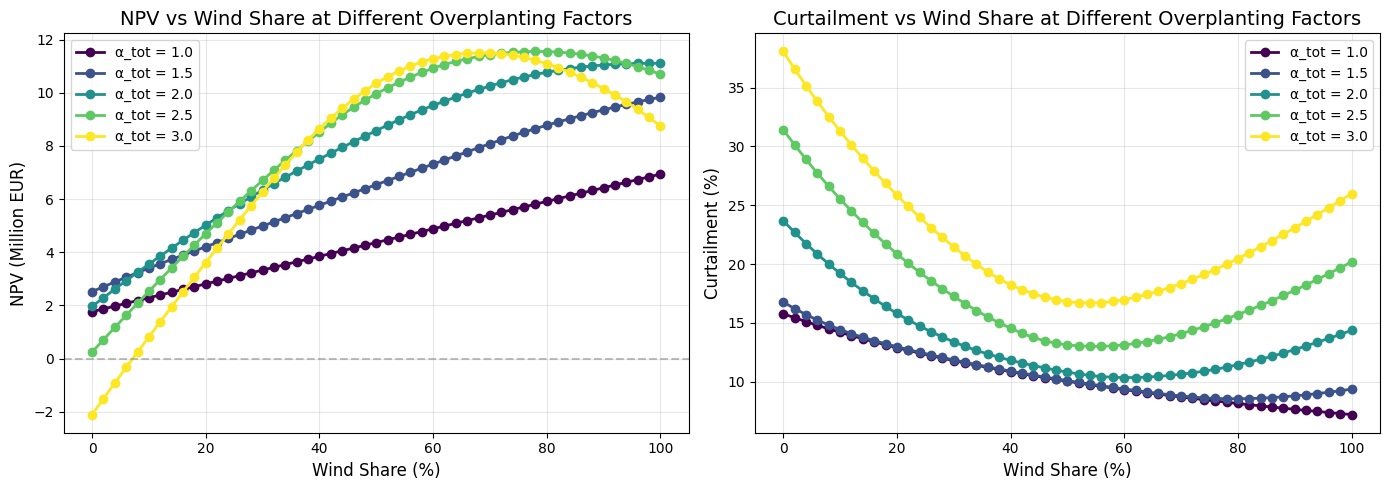

In [23]:
# Plot NPV vs wind share for selected overplanting factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Select a few representative overplanting factors
selected_alphas = [1.0, 1.5, 2.0, 2.5, 3.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_alphas)))

# Left plot: NPV vs wind share
ax1 = axes[0]
for i, alpha in enumerate(selected_alphas):
    subset = df_hybrid[df_hybrid["alpha_tot"] == alpha]
    ax1.plot(subset["s_wind"] * 100, subset["npv_eur"] / 1e6, 
             'o-', color=colors[i], label=f"α_tot = {alpha:.1f}", linewidth=2, markersize=6)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel("Wind Share (%)", fontsize=12)
ax1.set_ylabel("NPV (Million EUR)", fontsize=12)
ax1.set_title("NPV vs Wind Share at Different Overplanting Factors", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right plot: Curtailment vs wind share
ax2 = axes[1]
for i, alpha in enumerate(selected_alphas):
    subset = df_hybrid[df_hybrid["alpha_tot"] == alpha]
    ax2.plot(subset["s_wind"] * 100, subset["curtailment_pct"], 
             'o-', color=colors[i], label=f"α_tot = {alpha:.1f}", linewidth=2, markersize=6)

ax2.set_xlabel("Wind Share (%)", fontsize=12)
ax2.set_ylabel("Curtailment (%)", fontsize=12)
ax2.set_title("Curtailment vs Wind Share at Different Overplanting Factors", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "figures" / "hybrid_npv_vs_wind_share.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.3 Comparison: Stand-Alone vs Hybrid


In [24]:
# Compare optimal stand-alone vs hybrid configurations
comparison = pd.DataFrame({
    "Metric": [
        "Configuration",
        "Total Capacity (MW)",
        "PV Capacity (MW)",
        "Wind Capacity (MW)",
        "NPV (€)",
        "Annual Revenue Year 1 (€)",
        "Annual Export (MWh)",
        "Annual Curtailment (MWh)",
        "Curtailment (%)",
    ],
    "PV Only": [
        f"α = {pv_optimal.alpha:.1f}",
        f"{pv_optimal.capacity_mw:.1f}",
        f"{pv_optimal.capacity_mw:.1f}",
        "0.0",
        f"{pv_optimal.npv_eur:,.0f}",
        f"{pv_optimal.annual_revenue_eur:,.0f}",
        f"{pv_optimal.annual_export_mwh:,.0f}",
        f"{pv_optimal.annual_curtailment_mwh:,.0f}",
        f"{pv_optimal.annual_curtailment_mwh / (pv_optimal.annual_export_mwh + pv_optimal.annual_curtailment_mwh) * 100:.1f}%",
    ],
    "Wind Only": [
        f"α = {wind_optimal.alpha:.1f}",
        f"{wind_optimal.capacity_mw:.1f}",
        "0.0",
        f"{wind_optimal.capacity_mw:.1f}",
        f"{wind_optimal.npv_eur:,.0f}",
        f"{wind_optimal.annual_revenue_eur:,.0f}",
        f"{wind_optimal.annual_export_mwh:,.0f}",
        f"{wind_optimal.annual_curtailment_mwh:,.0f}",
        f"{wind_optimal.annual_curtailment_mwh / (wind_optimal.annual_export_mwh + wind_optimal.annual_curtailment_mwh) * 100:.1f}%",
    ],
    "Hybrid (Optimal)": [
        f"α_tot={best_hybrid.alpha_tot:.1f}, s_wind={best_hybrid.s_wind:.0%}",
        f"{best_hybrid.pv_capacity_mw + best_hybrid.wind_capacity_mw:.1f}",
        f"{best_hybrid.pv_capacity_mw:.1f}",
        f"{best_hybrid.wind_capacity_mw:.1f}",
        f"{best_hybrid.npv_eur:,.0f}",
        f"{best_hybrid.annual_revenue_eur_total:,.0f}",
        f"{best_hybrid.annual_export_mwh_total:,.0f}",
        f"{best_hybrid.annual_curtailment_mwh_total:,.0f}",
        f"{best_hybrid.annual_curtailment_mwh_total / (best_hybrid.annual_export_mwh_total + best_hybrid.annual_curtailment_mwh_total) * 100:.1f}%",
    ],
})

print("=" * 80)
print("COMPARISON: STAND-ALONE vs HYBRID CONFIGURATIONS")
print("=" * 80)
print(comparison.to_string(index=False))


COMPARISON: STAND-ALONE vs HYBRID CONFIGURATIONS
                   Metric   PV Only  Wind Only      Hybrid (Optimal)
            Configuration   α = 1.6    α = 2.1 α_tot=2.7, s_wind=74%
      Total Capacity (MW)      16.0       21.0                  27.0
         PV Capacity (MW)      16.0        0.0                   7.0
       Wind Capacity (MW)       0.0       21.0                  20.0
                  NPV (€) 2,540,303 11,168,145            11,615,082
Annual Revenue Year 1 (€)   988,848  3,108,463             3,383,627
      Annual Export (MWh)    15,236     41,643                45,985
 Annual Curtailment (MWh)     3,300      7,633                 9,030
          Curtailment (%)     17.8%      15.5%                 16.4%


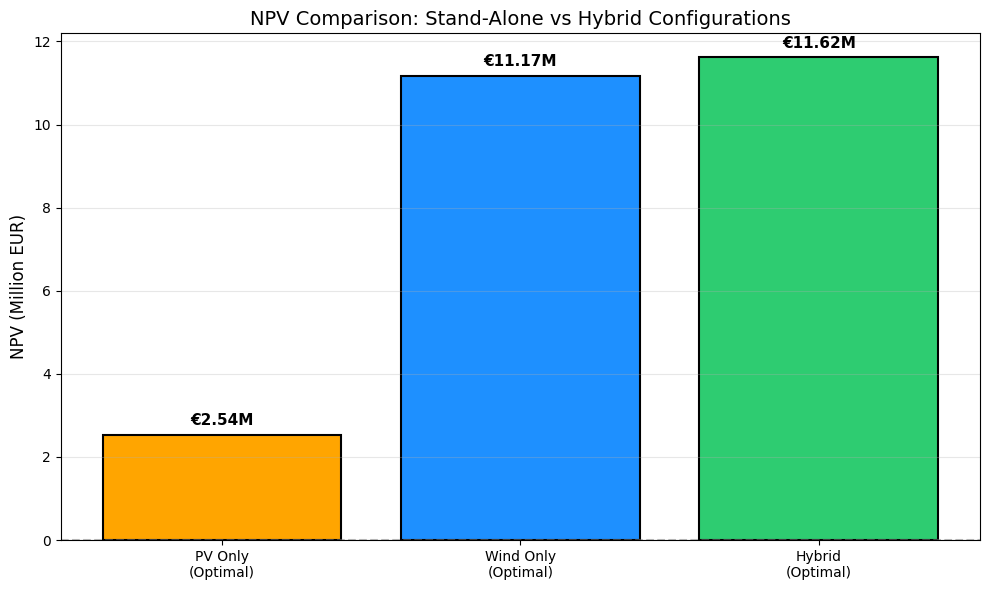

In [25]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))

configs = ["PV Only\n(Optimal)", "Wind Only\n(Optimal)", "Hybrid\n(Optimal)"]
npvs = [pv_optimal.npv_eur / 1e6, wind_optimal.npv_eur / 1e6, best_hybrid.npv_eur / 1e6]
colors_bar = [pv_color, wind_color, "#2ECC71"]  # Green for hybrid

bars = ax.bar(configs, npvs, color=colors_bar, edgecolor='black', linewidth=1.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel("NPV (Million EUR)", fontsize=12)
ax.set_title("NPV Comparison: Stand-Alone vs Hybrid Configurations", fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, npvs):
    height = bar.get_height()
    ax.annotate(f"€{val:.2f}M",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(project_root / "figures" / "npv_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
# Save hybrid results to CSV
df_hybrid.to_csv(project_root / "data_processed" / "hybrid_oversizing_results.csv", index=False)
print("Hybrid results saved to data_processed/hybrid_oversizing_results.csv")


Hybrid results saved to data_processed/hybrid_oversizing_results.csv


---

## 7. POI Utilization Analysis

Analyzing how efficiently each configuration uses the 10 MW grid connection.


In [27]:
# Reload modules to pick up new POI utilization fields
import importlib
import oversizing_analysis
import hybrid_analysis
importlib.reload(oversizing_analysis)
importlib.reload(hybrid_analysis)

from oversizing_analysis import (
    evaluate_oversizing_grid,
    find_optimal_alpha,
    results_to_dataframe,
)
from hybrid_analysis import (
    evaluate_hybrid_grid,
    find_best_hybrid_by_npv,
    results_to_dataframe as hybrid_results_to_dataframe,
)

# Re-run stand-alone analysis with new fields
pv_results = evaluate_oversizing_grid(df, "pv", alphas)
wind_results = evaluate_oversizing_grid(df, "wind", alphas)

# Find optimal configurations
pv_optimal = find_optimal_alpha(pv_results)
wind_optimal = find_optimal_alpha(wind_results)

# Convert to DataFrames
df_pv = results_to_dataframe(pv_results)
df_wind = results_to_dataframe(wind_results)

# Re-run hybrid analysis with new fields
hybrid_results = evaluate_hybrid_grid(df, alpha_tot_values, s_wind_values)
best_hybrid = find_best_hybrid_by_npv(hybrid_results)
df_hybrid = hybrid_results_to_dataframe(hybrid_results)

print("Modules reloaded and analysis re-run with new POI utilization fields")
print(f"df_pv columns: {list(df_pv.columns)}")
print(f"df_hybrid columns: {list(df_hybrid.columns)}")


Modules reloaded and analysis re-run with new POI utilization fields
df_pv columns: ['tech', 'alpha', 'capacity_mw', 'npv_eur', 'irr', 'annual_revenue_eur', 'annual_export_mwh', 'annual_curtailment_mwh', 'export_per_mw_poi_mwh', 'poi_utilisation_factor', 'capex_total_eur', 'annual_opex_total_eur', 'wacc', 'lifetime_years']
df_hybrid columns: ['alpha_tot', 's_wind', 'pv_capacity_mw', 'wind_capacity_mw', 'wacc', 'npv_eur', 'irr', 'annual_revenue_eur_total', 'annual_revenue_eur_pv', 'annual_revenue_eur_wind', 'annual_export_mwh_total', 'annual_export_mwh_pv', 'annual_export_mwh_wind', 'annual_curtailment_mwh_total', 'annual_curtailment_mwh_pv', 'annual_curtailment_mwh_wind', 'export_per_mw_poi_mwh', 'poi_utilisation_factor', 'capex_pv_eur', 'capex_wind_eur', 'capex_total_eur', 'annual_opex_pv_eur', 'annual_opex_wind_eur', 'annual_opex_total_eur']


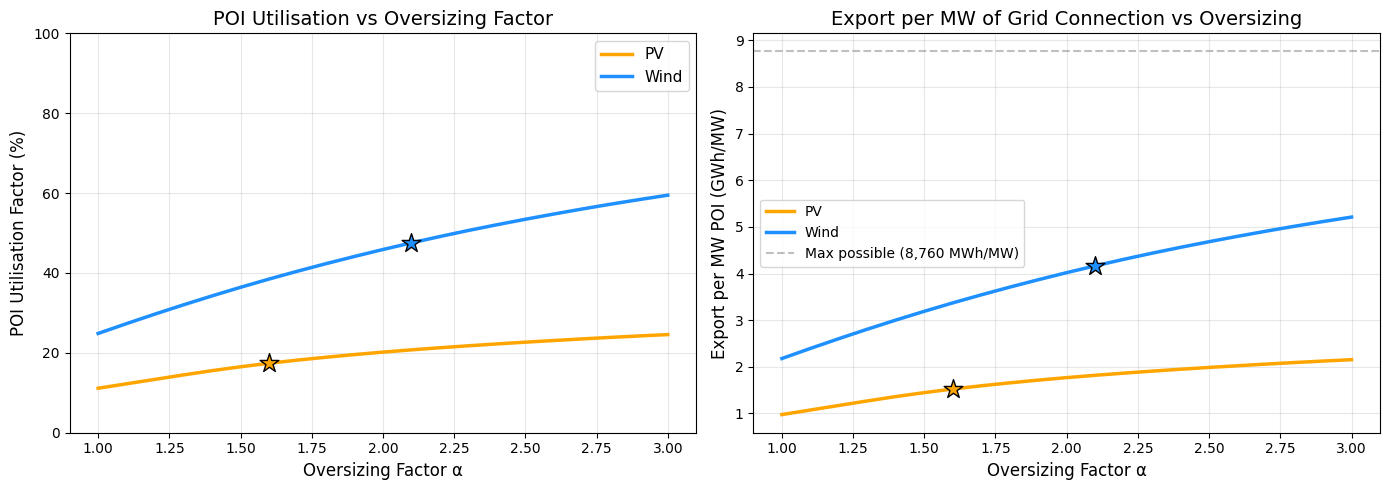


PV optimal (α=1.60): POI utilisation = 17.4%
Wind optimal (α=2.10): POI utilisation = 47.5%


In [28]:
# POI Utilization for Stand-Alone Technologies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: POI Utilization Factor vs Alpha
ax1 = axes[0]
ax1.plot(df_pv["alpha"], df_pv["poi_utilisation_factor"] * 100, "-", 
         label="PV", color=pv_color, linewidth=2.5)
ax1.plot(df_wind["alpha"], df_wind["poi_utilisation_factor"] * 100, "-", 
         label="Wind", color=wind_color, linewidth=2.5)
ax1.scatter([pv_optimal.alpha], [pv_optimal.poi_utilisation_factor * 100], 
            color=pv_color, s=200, marker="*", edgecolors="black", zorder=5)
ax1.scatter([wind_optimal.alpha], [wind_optimal.poi_utilisation_factor * 100], 
            color=wind_color, s=200, marker="*", edgecolors="black", zorder=5)
ax1.set_xlabel("Oversizing Factor α", fontsize=12)
ax1.set_ylabel("POI Utilisation Factor (%)", fontsize=12)
ax1.set_title("POI Utilisation vs Oversizing Factor", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Right plot: Export per MW POI vs Alpha
ax2 = axes[1]
ax2.plot(df_pv["alpha"], df_pv["export_per_mw_poi_mwh"] / 1000, "-", 
         label="PV", color=pv_color, linewidth=2.5)
ax2.plot(df_wind["alpha"], df_wind["export_per_mw_poi_mwh"] / 1000, "-", 
         label="Wind", color=wind_color, linewidth=2.5)
ax2.scatter([pv_optimal.alpha], [pv_optimal.export_per_mw_poi_mwh / 1000], 
            color=pv_color, s=200, marker="*", edgecolors="black", zorder=5)
ax2.scatter([wind_optimal.alpha], [wind_optimal.export_per_mw_poi_mwh / 1000], 
            color=wind_color, s=200, marker="*", edgecolors="black", zorder=5)
ax2.axhline(y=8.76, color="gray", linestyle="--", alpha=0.5, label="Max possible (8,760 MWh/MW)")
ax2.set_xlabel("Oversizing Factor α", fontsize=12)
ax2.set_ylabel("Export per MW POI (GWh/MW)", fontsize=12)
ax2.set_title("Export per MW of Grid Connection vs Oversizing", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "figures" / "poi_utilisation_standalone.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPV optimal (α={pv_optimal.alpha:.2f}): POI utilisation = {pv_optimal.poi_utilisation_factor*100:.1f}%")
print(f"Wind optimal (α={wind_optimal.alpha:.2f}): POI utilisation = {wind_optimal.poi_utilisation_factor*100:.1f}%")


### 7.1 Hybrid POI Utilization Heatmap


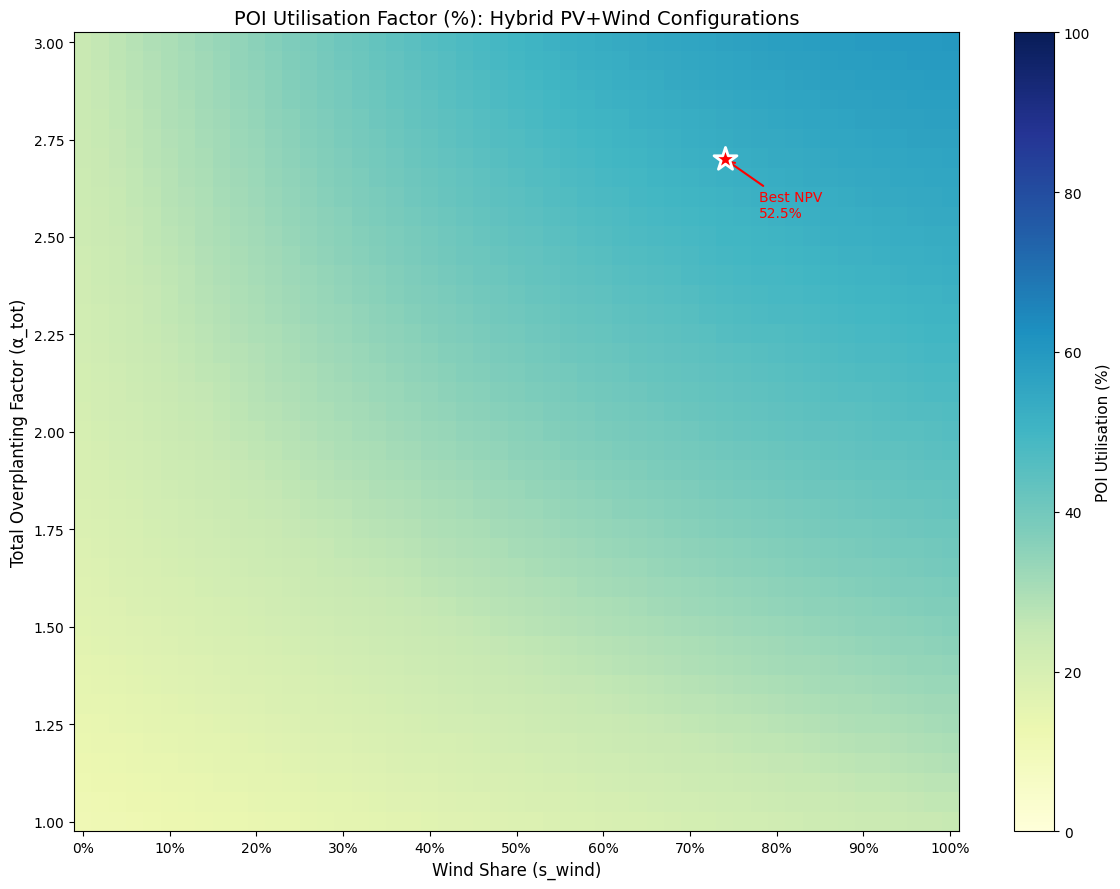

In [29]:
# Create POI Utilization heatmap for hybrid configurations
poi_util_matrix = df_hybrid.pivot(index="alpha_tot", columns="s_wind", values="poi_utilisation_factor")

fig, ax = plt.subplots(figsize=(12, 9))

# Plot heatmap
im = ax.imshow(
    poi_util_matrix.values * 100, 
    aspect='auto', 
    origin='lower', 
    cmap='YlGnBu',
    vmin=0,
    vmax=100,
)

# Set axis labels - show every 10% for wind share (every 5th value with 2% steps)
x_tick_interval = 5  # Show every 5th tick (0%, 10%, 20%, ...)
x_ticks = range(0, len(poi_util_matrix.columns), x_tick_interval)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{poi_util_matrix.columns[i]:.0%}" for i in x_ticks], fontsize=10)

# Show every 5th alpha value (every 0.25)
y_tick_interval = 5
y_ticks = range(0, len(poi_util_matrix.index), y_tick_interval)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{poi_util_matrix.index[i]:.2f}" for i in y_ticks], fontsize=10)

ax.set_xlabel("Wind Share (s_wind)", fontsize=12)
ax.set_ylabel("Total Overplanting Factor (α_tot)", fontsize=12)
ax.set_title("POI Utilisation Factor (%): Hybrid PV+Wind Configurations", fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("POI Utilisation (%)", fontsize=11)

# Mark optimal NPV point
best_row = list(poi_util_matrix.index).index(best_hybrid.alpha_tot)
best_col = list(poi_util_matrix.columns).index(best_hybrid.s_wind)
ax.scatter([best_col], [best_row], color='red', s=300, marker='*', 
           edgecolors='white', linewidths=2, zorder=5)
ax.annotate(f"Best NPV\n{best_hybrid.poi_utilisation_factor*100:.1f}%", 
            xy=(best_col, best_row), xytext=(best_col + 2, best_row - 3),
            fontsize=10, ha='left', color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.tight_layout()
plt.savefig(project_root / "figures" / "hybrid_poi_utilisation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.2 NPV vs POI Utilization: Is there a trade-off?

Let's examine whether maximizing NPV comes at the cost of grid utilization (or vice versa).


Correlation between NPV and POI Utilization: 0.862
→ Strong POSITIVE correlation: NO trade-off exists!
  Wind-heavy configurations achieve high NPV AND high POI utilization.


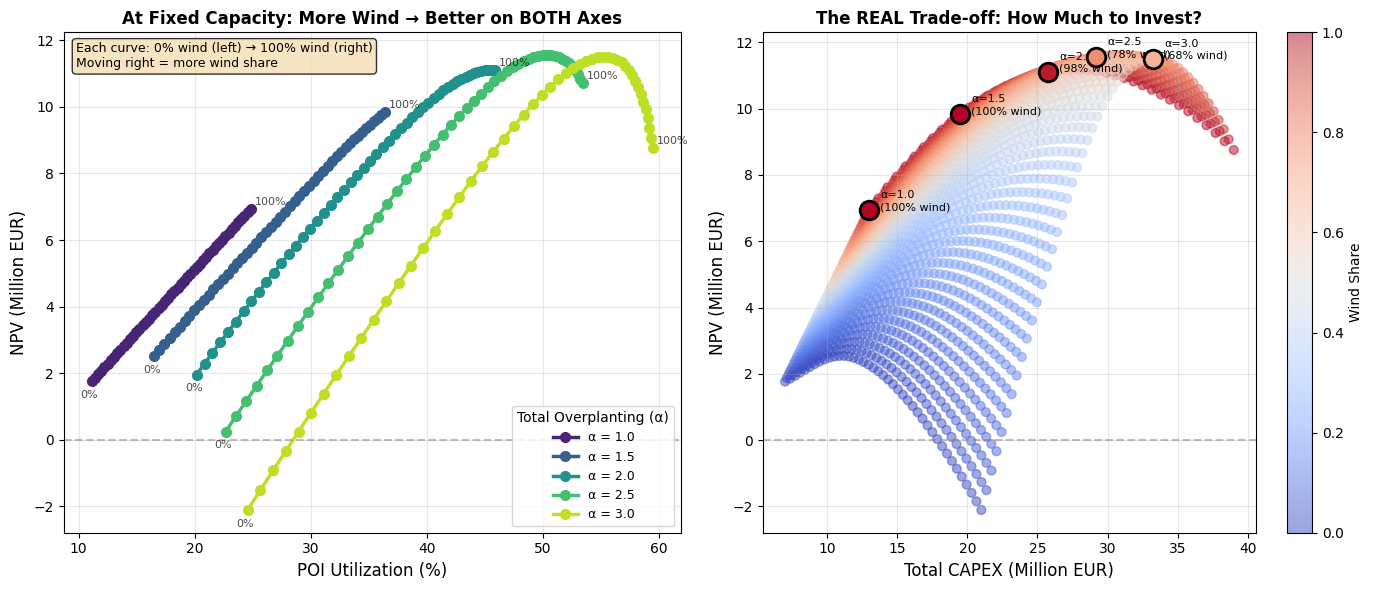


Key insight: There is NO NPV vs POI utilization trade-off (corr = 0.86).
Wind-heavy configurations dominate on both metrics.
The real decision is about investment scale (CAPEX) vs returns (NPV).


In [30]:
# Calculate correlation between NPV and POI utilization
corr = df_hybrid["npv_eur"].corr(df_hybrid["poi_utilisation_factor"])
print(f"Correlation between NPV and POI Utilization: {corr:.3f}")
if corr > 0.5:
    print("→ Strong POSITIVE correlation: NO trade-off exists!")
    print("  Wind-heavy configurations achieve high NPV AND high POI utilization.")

# Add CAPEX column for analysis
CAPEX_PV = 700  # EUR/kW
CAPEX_WIND = 1300  # EUR/kW
df_hybrid["capex_million"] = (
    df_hybrid["pv_capacity_mw"] * 1000 * CAPEX_PV + 
    df_hybrid["wind_capacity_mw"] * 1000 * CAPEX_WIND
) / 1e6

# Create a cleaner 2-panel visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: NPV vs POI at fixed capacity levels (iso-α curves)
ax1 = axes[0]
selected_alphas = [1.0, 1.5, 2.0, 2.5, 3.0]
colors_alpha = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_alphas)))

for alpha, color in zip(selected_alphas, colors_alpha):
    subset = df_hybrid[df_hybrid["alpha_tot"] == alpha].sort_values("s_wind")
    line, = ax1.plot(
        subset["poi_utilisation_factor"] * 100, 
        subset["npv_eur"] / 1e6,
        'o-', color=color, linewidth=2.5, markersize=7, 
        label=f"α = {alpha:.1f}"
    )
    # Annotate start (0% wind) and end (100% wind) of each curve
    if len(subset) > 0:
        start = subset.iloc[0]
        end = subset.iloc[-1]
        ax1.annotate("0%", (start["poi_utilisation_factor"]*100, start["npv_eur"]/1e6),
                    fontsize=8, alpha=0.7, xytext=(-8, -12), textcoords='offset points')
        ax1.annotate("100%", (end["poi_utilisation_factor"]*100, end["npv_eur"]/1e6),
                    fontsize=8, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("POI Utilization (%)", fontsize=12)
ax1.set_ylabel("NPV (Million EUR)", fontsize=12)
ax1.set_title("At Fixed Capacity: More Wind → Better on BOTH Axes", fontsize=12, fontweight='bold')
ax1.legend(title="Total Overplanting (α)", loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.3)

# Add annotation explaining the curves
ax1.text(0.02, 0.98, "Each curve: 0% wind (left) → 100% wind (right)\nMoving right = more wind share",
         transform=ax1.transAxes, fontsize=9, va='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Panel 2: The REAL trade-off - Investment vs Returns
ax2 = axes[1]
scatter = ax2.scatter(
    df_hybrid["capex_million"], 
    df_hybrid["npv_eur"] / 1e6,
    c=df_hybrid["s_wind"], 
    cmap="coolwarm", 
    alpha=0.5, 
    s=40
)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label("Wind Share", fontsize=10)

# Highlight optimal at each capacity level
for alpha, color in zip(selected_alphas, colors_alpha):
    subset = df_hybrid[df_hybrid["alpha_tot"] == alpha]
    best = subset.loc[subset["npv_eur"].idxmax()]
    ax2.scatter(
        best["capex_million"], best["npv_eur"] / 1e6,
        s=180, edgecolors='black', linewidths=2,
        c=[best["s_wind"]], cmap='coolwarm', vmin=0, vmax=1, zorder=5
    )
    ax2.annotate(
        f"α={alpha:.1f}\n({best['s_wind']:.0%} wind)", 
        (best["capex_million"], best["npv_eur"] / 1e6),
        xytext=(8, 0), textcoords='offset points', fontsize=8
    )

ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Total CAPEX (Million EUR)", fontsize=12)
ax2.set_ylabel("NPV (Million EUR)", fontsize=12)
ax2.set_title("The REAL Trade-off: How Much to Invest?", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "figures" / "npv_poi_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKey insight: There is NO NPV vs POI utilization trade-off (corr = {corr:.2f}).")
print("Wind-heavy configurations dominate on both metrics.")
print("The real decision is about investment scale (CAPEX) vs returns (NPV).")


### 7.2.1 Detailed Comparison: PV-only vs Wind-only vs Hybrid

Let's compare three key configurations in detail to understand the marginal benefit of adding a small PV share to the wind-dominated portfolio.


In [31]:
# Compute detailed comparison table for three key configurations
from economics import irr, build_cash_flows_single_tech, build_cash_flows_hybrid_pv_wind
from config import (
    CAPEX_PV_EUR_PER_KW, CAPEX_WIND_EUR_PER_KW,
    OPEX_PV_EUR_PER_KW_PER_YEAR, OPEX_WIND_EUR_PER_KW_PER_YEAR,
    LIFETIME_PV_YEARS, LIFETIME_WIND_YEARS,
    DEGRADATION_PV_PER_YEAR, WACC_PV_REAL, WACC_WIND_REAL
)

# Helper function to compute IRR for a configuration
def compute_config_irr(config_type, config_data):
    """Compute IRR for a given configuration."""
    if config_type == "pv":
        capex = config_data.alpha * 10 * 1000 * CAPEX_PV_EUR_PER_KW  # MW to kW
        annual_opex = config_data.alpha * 10 * 1000 * OPEX_PV_EUR_PER_KW_PER_YEAR
        cf = build_cash_flows_single_tech(
            config_data.annual_revenue_eur, annual_opex, 
            LIFETIME_PV_YEARS, WACC_PV_REAL, DEGRADATION_PV_PER_YEAR
        )
    elif config_type == "wind":
        capex = config_data.alpha * 10 * 1000 * CAPEX_WIND_EUR_PER_KW
        annual_opex = config_data.alpha * 10 * 1000 * OPEX_WIND_EUR_PER_KW_PER_YEAR
        cf = build_cash_flows_single_tech(
            config_data.annual_revenue_eur, annual_opex,
            LIFETIME_WIND_YEARS, WACC_WIND_REAL, 0.0
        )
    else:  # hybrid
        capex_pv = config_data.pv_capacity_mw * 1000 * CAPEX_PV_EUR_PER_KW
        capex_wind = config_data.wind_capacity_mw * 1000 * CAPEX_WIND_EUR_PER_KW
        capex = capex_pv + capex_wind
        annual_opex_pv = config_data.pv_capacity_mw * 1000 * OPEX_PV_EUR_PER_KW_PER_YEAR
        annual_opex_wind = config_data.wind_capacity_mw * 1000 * OPEX_WIND_EUR_PER_KW_PER_YEAR
        cf = build_cash_flows_hybrid_pv_wind(
            config_data.annual_revenue_eur_pv, config_data.annual_revenue_eur_wind,
            annual_opex_pv, annual_opex_wind,
            LIFETIME_PV_YEARS, LIFETIME_WIND_YEARS,
            DEGRADATION_PV_PER_YEAR
        )
    
    # Build full cash flow with initial investment
    full_cf = np.concatenate([[-capex], cf])
    try:
        irr = compute_irr(full_cf)
        return irr
    except:
        return np.nan

# Find the hybrid configuration at exactly 90% wind with optimal alpha
hybrid_90_wind = df_hybrid[df_hybrid["s_wind"] == 0.90].sort_values("npv_eur", ascending=False).iloc[0]

# Get matching HybridResult object for the 90% wind config
hybrid_90_result = None
for r in hybrid_results:
    if r.alpha_tot == hybrid_90_wind["alpha_tot"] and r.s_wind == 0.90:
        hybrid_90_result = r
        break

# Compute IRRs
irr_pv = compute_config_irr("pv", pv_optimal)
irr_wind = compute_config_irr("wind", wind_optimal)
irr_hybrid = compute_config_irr("hybrid", best_hybrid)

# Create comparison table
comparison_data = {
    "Configuration": [
        f"PV-only (α={pv_optimal.alpha:.2f})",
        f"Wind-only (α={wind_optimal.alpha:.2f})",
        f"Hybrid 90% Wind (α={best_hybrid.alpha_tot:.2f})"
    ],
    "Installed Capacity (MW)": [
        f"{pv_optimal.alpha * 10:.1f}",
        f"{wind_optimal.alpha * 10:.1f}",
        f"{best_hybrid.pv_capacity_mw + best_hybrid.wind_capacity_mw:.1f}"
    ],
    "PV / Wind (MW)": [
        f"{pv_optimal.alpha * 10:.1f} / 0",
        f"0 / {wind_optimal.alpha * 10:.1f}",
        f"{best_hybrid.pv_capacity_mw:.1f} / {best_hybrid.wind_capacity_mw:.1f}"
    ],
    "NPV (€M)": [
        f"{pv_optimal.npv_eur / 1e6:.2f}",
        f"{wind_optimal.npv_eur / 1e6:.2f}",
        f"{best_hybrid.npv_eur / 1e6:.2f}"
    ],
    "IRR (%)": [
        f"{irr_pv * 100:.1f}%" if not np.isnan(irr_pv) else "N/A",
        f"{irr_wind * 100:.1f}%" if not np.isnan(irr_wind) else "N/A",
        f"{irr_hybrid * 100:.1f}%" if not np.isnan(irr_hybrid) else "N/A"
    ],
    "Exported (MWh/yr)": [
        f"{pv_optimal.annual_export_mwh:,.0f}",
        f"{wind_optimal.annual_export_mwh:,.0f}",
        f"{best_hybrid.annual_export_mwh_total:,.0f}"
    ],
    "Curtailed (MWh/yr)": [
        f"{pv_optimal.annual_curtailment_mwh:,.0f}",
        f"{wind_optimal.annual_curtailment_mwh:,.0f}",
        f"{best_hybrid.annual_curtailment_mwh_total:,.0f}"
    ],
    "POI Utilization (%)": [
        f"{pv_optimal.poi_utilisation_factor * 100:.1f}",
        f"{wind_optimal.poi_utilisation_factor * 100:.1f}",
        f"{best_hybrid.poi_utilisation_factor * 100:.1f}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("=" * 90)
print("DETAILED COMPARISON: PV-only vs Wind-only vs Hybrid (90% Wind)")
print("=" * 90)
print(df_comparison.to_string(index=False))
print("\n")

# Show relative improvements
print("Key observations:")
print(f"  • Hybrid vs Wind-only: NPV +€{(best_hybrid.npv_eur - wind_optimal.npv_eur)/1e6:.2f}M (+{(best_hybrid.npv_eur/wind_optimal.npv_eur - 1)*100:.1f}%)")
print(f"  • Hybrid vs Wind-only: POI util {best_hybrid.poi_utilisation_factor*100:.1f}% vs {wind_optimal.poi_utilisation_factor*100:.1f}%")
print(f"  • Adding {best_hybrid.pv_capacity_mw:.1f} MW PV to wind gives marginal diversification benefit")


DETAILED COMPARISON: PV-only vs Wind-only vs Hybrid (90% Wind)
           Configuration Installed Capacity (MW) PV / Wind (MW) NPV (€M) IRR (%) Exported (MWh/yr) Curtailed (MWh/yr) POI Utilization (%)
        PV-only (α=1.60)                    16.0       16.0 / 0     2.54     N/A            15,236              3,300                17.4
      Wind-only (α=2.10)                    21.0       0 / 21.0    11.17     N/A            41,643              7,633                47.5
Hybrid 90% Wind (α=2.70)                    27.0     7.0 / 20.0    11.62     N/A            45,985              9,030                52.5


Key observations:
  • Hybrid vs Wind-only: NPV +€0.45M (+4.0%)
  • Hybrid vs Wind-only: POI util 52.5% vs 47.5%
  • Adding 7.0 MW PV to wind gives marginal diversification benefit


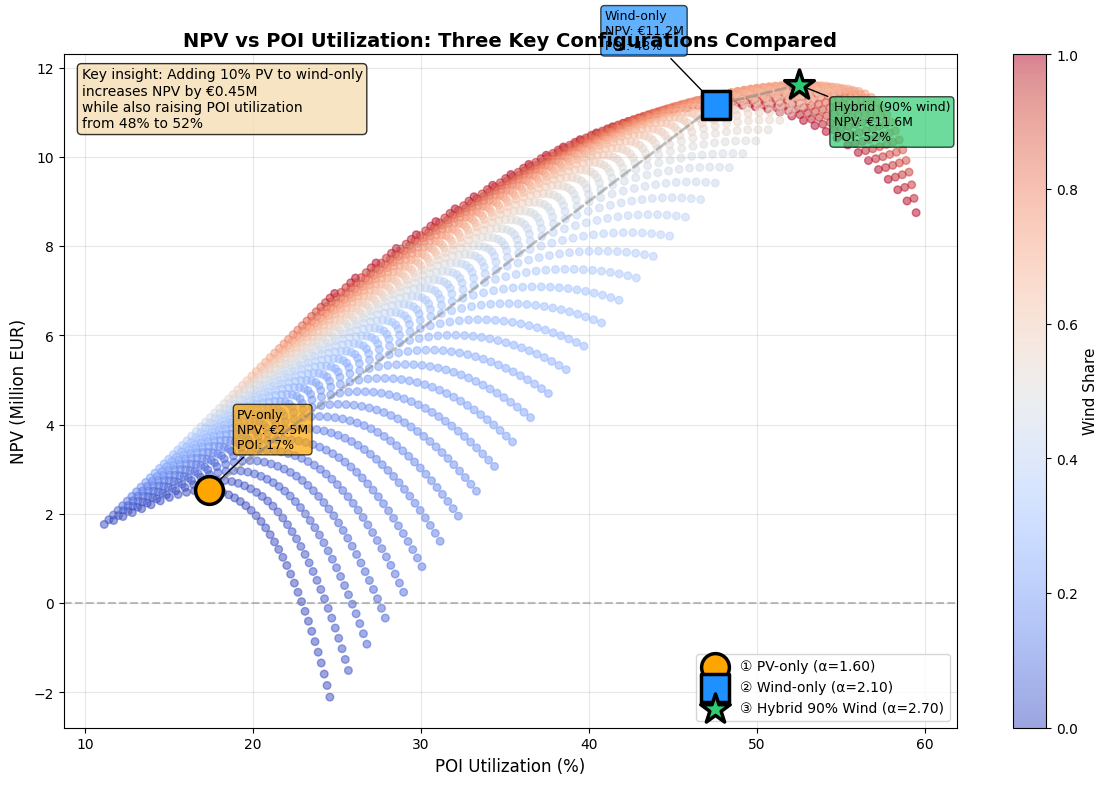

In [32]:
# Plot NPV vs POI Utilization with three key configurations highlighted
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all hybrid configurations as small dots, colored by wind share
scatter = ax.scatter(
    df_hybrid["poi_utilisation_factor"] * 100,
    df_hybrid["npv_eur"] / 1e6,
    c=df_hybrid["s_wind"],
    cmap="coolwarm",
    s=30,
    alpha=0.5,
    zorder=1
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Wind Share", fontsize=11)

# Mark the three key configurations with large, distinct markers
# 1. PV optimal
ax.scatter(
    pv_optimal.poi_utilisation_factor * 100, 
    pv_optimal.npv_eur / 1e6,
    s=400, c=pv_color, marker="o", edgecolors="black", linewidths=2.5,
    zorder=5, label=f"① PV-only (α={pv_optimal.alpha:.2f})"
)
ax.annotate(
    f"PV-only\nNPV: €{pv_optimal.npv_eur/1e6:.1f}M\nPOI: {pv_optimal.poi_utilisation_factor*100:.0f}%",
    (pv_optimal.poi_utilisation_factor * 100, pv_optimal.npv_eur / 1e6),
    xytext=(20, 30), textcoords='offset points', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor=pv_color, alpha=0.7),
    arrowprops=dict(arrowstyle='->', color='black')
)

# 2. Wind optimal  
ax.scatter(
    wind_optimal.poi_utilisation_factor * 100,
    wind_optimal.npv_eur / 1e6,
    s=400, c=wind_color, marker="s", edgecolors="black", linewidths=2.5,
    zorder=5, label=f"② Wind-only (α={wind_optimal.alpha:.2f})"
)
ax.annotate(
    f"Wind-only\nNPV: €{wind_optimal.npv_eur/1e6:.1f}M\nPOI: {wind_optimal.poi_utilisation_factor*100:.0f}%",
    (wind_optimal.poi_utilisation_factor * 100, wind_optimal.npv_eur / 1e6),
    xytext=(-80, 40), textcoords='offset points', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor=wind_color, alpha=0.7),
    arrowprops=dict(arrowstyle='->', color='black')
)

# 3. Hybrid optimal (90% wind)
ax.scatter(
    best_hybrid.poi_utilisation_factor * 100,
    best_hybrid.npv_eur / 1e6,
    s=500, c="#2ECC71", marker="*", edgecolors="black", linewidths=2.5,
    zorder=6, label=f"③ Hybrid 90% Wind (α={best_hybrid.alpha_tot:.2f})"
)
ax.annotate(
    f"Hybrid (90% wind)\nNPV: €{best_hybrid.npv_eur/1e6:.1f}M\nPOI: {best_hybrid.poi_utilisation_factor*100:.0f}%",
    (best_hybrid.poi_utilisation_factor * 100, best_hybrid.npv_eur / 1e6),
    xytext=(25, -40), textcoords='offset points', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2ECC71', alpha=0.7),
    arrowprops=dict(arrowstyle='->', color='black')
)

# Draw arrows showing the "path" from PV to Wind to Hybrid
# This shows how mixing technologies moves you through the space
ax.annotate("", xy=(wind_optimal.poi_utilisation_factor * 100, wind_optimal.npv_eur / 1e6),
            xytext=(pv_optimal.poi_utilisation_factor * 100, pv_optimal.npv_eur / 1e6),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2, ls='--', alpha=0.5))

ax.annotate("", xy=(best_hybrid.poi_utilisation_factor * 100, best_hybrid.npv_eur / 1e6),
            xytext=(wind_optimal.poi_utilisation_factor * 100, wind_optimal.npv_eur / 1e6),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2, ls='--', alpha=0.5))

ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("POI Utilization (%)", fontsize=12)
ax.set_ylabel("NPV (Million EUR)", fontsize=12)
ax.set_title("NPV vs POI Utilization: Three Key Configurations Compared", fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

# Add text box explaining the insight
textstr = ("Key insight: Adding 10% PV to wind-only\n"
           f"increases NPV by €{(best_hybrid.npv_eur - wind_optimal.npv_eur)/1e6:.2f}M\n"
           f"while also raising POI utilization\n"
           f"from {wind_optimal.poi_utilisation_factor*100:.0f}% to {best_hybrid.poi_utilisation_factor*100:.0f}%")
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(project_root / "figures" / "npv_poi_three_configs.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 POI Utilization Summary


In [33]:
# Summary table with POI utilization metrics
poi_summary = pd.DataFrame({
    "Configuration": ["PV Only (Optimal)", "Wind Only (Optimal)", "Hybrid (Optimal)"],
    "Capacity (MW)": [
        f"{pv_optimal.capacity_mw:.1f}",
        f"{wind_optimal.capacity_mw:.1f}",
        f"{best_hybrid.pv_capacity_mw + best_hybrid.wind_capacity_mw:.1f}",
    ],
    "NPV (€M)": [
        f"{pv_optimal.npv_eur/1e6:.2f}",
        f"{wind_optimal.npv_eur/1e6:.2f}",
        f"{best_hybrid.npv_eur/1e6:.2f}",
    ],
    "Annual Export (GWh)": [
        f"{pv_optimal.annual_export_mwh/1e3:.2f}",
        f"{wind_optimal.annual_export_mwh/1e3:.2f}",
        f"{best_hybrid.annual_export_mwh_total/1e3:.2f}",
    ],
    "Export/MW POI (GWh)": [
        f"{pv_optimal.export_per_mw_poi_mwh/1e3:.2f}",
        f"{wind_optimal.export_per_mw_poi_mwh/1e3:.2f}",
        f"{best_hybrid.export_per_mw_poi_mwh/1e3:.2f}",
    ],
    "POI Utilisation (%)": [
        f"{pv_optimal.poi_utilisation_factor*100:.1f}",
        f"{wind_optimal.poi_utilisation_factor*100:.1f}",
        f"{best_hybrid.poi_utilisation_factor*100:.1f}",
    ],
})

print("=" * 80)
print("POI UTILISATION COMPARISON")
print("=" * 80)
print(f"Maximum possible POI utilisation: 100% (8,760 MWh/MW/year)")
print()
print(poi_summary.to_string(index=False))


POI UTILISATION COMPARISON
Maximum possible POI utilisation: 100% (8,760 MWh/MW/year)

      Configuration Capacity (MW) NPV (€M) Annual Export (GWh) Export/MW POI (GWh) POI Utilisation (%)
  PV Only (Optimal)          16.0     2.54               15.24                1.52                17.4
Wind Only (Optimal)          21.0    11.17               41.64                4.16                47.5
   Hybrid (Optimal)          27.0    11.62               45.98                4.60                52.5


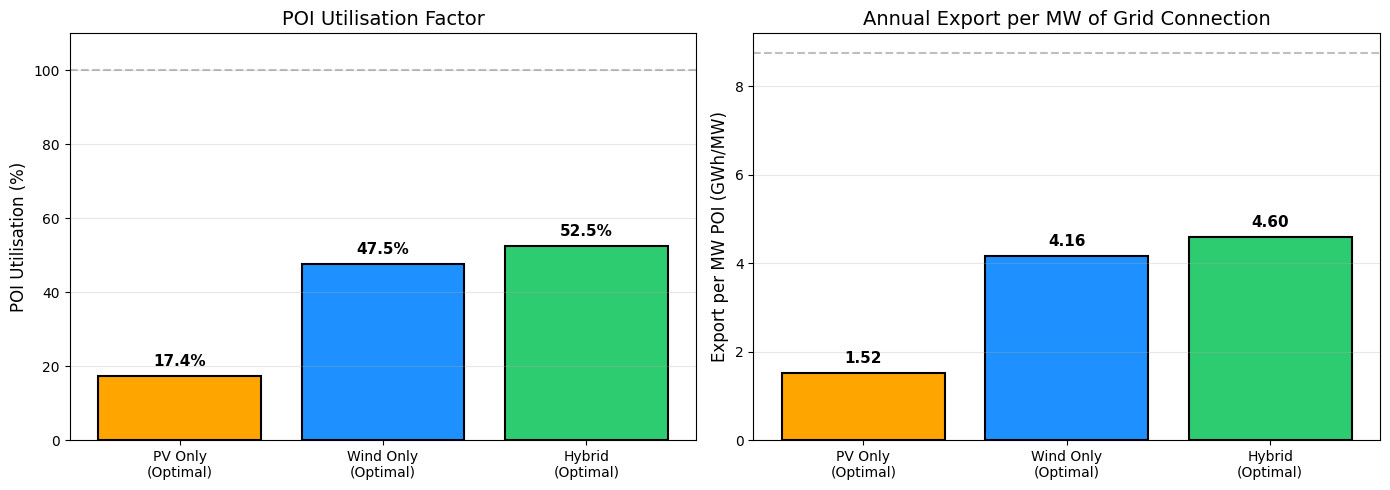

In [34]:
# Bar chart: POI Utilization comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = ["PV Only\n(Optimal)", "Wind Only\n(Optimal)", "Hybrid\n(Optimal)"]
colors_bar = [pv_color, wind_color, "#2ECC71"]

# Left: POI Utilization
ax1 = axes[0]
poi_utils = [
    pv_optimal.poi_utilisation_factor * 100,
    wind_optimal.poi_utilisation_factor * 100,
    best_hybrid.poi_utilisation_factor * 100,
]
bars1 = ax1.bar(configs, poi_utils, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Max possible')
ax1.set_ylabel("POI Utilisation (%)", fontsize=12)
ax1.set_title("POI Utilisation Factor", fontsize=14)
ax1.set_ylim(0, 110)
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, poi_utils):
    ax1.annotate(f"{val:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, val),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: Export per MW POI
ax2 = axes[1]
exports = [
    pv_optimal.export_per_mw_poi_mwh / 1000,
    wind_optimal.export_per_mw_poi_mwh / 1000,
    best_hybrid.export_per_mw_poi_mwh / 1000,
]
bars2 = ax2.bar(configs, exports, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.axhline(y=8.76, color='gray', linestyle='--', alpha=0.5, label='Max (8.76 GWh)')
ax2.set_ylabel("Export per MW POI (GWh/MW)", fontsize=12)
ax2.set_title("Annual Export per MW of Grid Connection", fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, exports):
    ax2.annotate(f"{val:.2f}", xy=(bar.get_x() + bar.get_width() / 2, val),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(project_root / "figures" / "poi_utilisation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.4 Diagnostic: Why is Wind-Only Optimal for POI Utilization?


In [35]:
# Diagnostic: Investigate why wind dominates POI utilization

# 1. Raw capacity factors (without any curtailment or price effects)
pv_capacity_factor = df["pv_per_kw"].sum() / 8760  # kWh per kW per year / hours
wind_capacity_factor = df["wind_per_kw"].sum() / 8760

print("=" * 70)
print("DIAGNOSTIC: CAPACITY FACTORS AND GENERATION PROFILES")
print("=" * 70)
print(f"\n1. RAW CAPACITY FACTORS (before any curtailment):")
print(f"   PV:   {pv_capacity_factor*100:.1f}%  ({df['pv_per_kw'].sum():.0f} kWh/kW/year)")
print(f"   Wind: {wind_capacity_factor*100:.1f}%  ({df['wind_per_kw'].sum():.0f} kWh/kW/year)")
print(f"   Ratio (Wind/PV): {wind_capacity_factor/pv_capacity_factor:.2f}x")

# 2. Correlation between PV and Wind generation
correlation = df["pv_per_kw"].corr(df["wind_per_kw"])
print(f"\n2. PV-WIND GENERATION CORRELATION: {correlation:.3f}")
print(f"   (Negative = complementary, Positive = overlapping)")

# 3. Hours with negative prices and their overlap with generation
negative_price_hours = df["price_eur_per_mwh"] < 0
n_negative_hours = negative_price_hours.sum()
pv_gen_during_negative = df.loc[negative_price_hours, "pv_per_kw"].sum()
wind_gen_during_negative = df.loc[negative_price_hours, "wind_per_kw"].sum()

print(f"\n3. ECONOMIC CURTAILMENT (negative price hours):")
print(f"   Total negative price hours: {n_negative_hours} ({n_negative_hours/87.6:.1f}% of year)")
print(f"   PV generation during negative prices:   {pv_gen_during_negative:.0f} kWh/kW ({pv_gen_during_negative/df['pv_per_kw'].sum()*100:.1f}% of total PV)")
print(f"   Wind generation during negative prices: {wind_gen_during_negative:.0f} kWh/kW ({wind_gen_during_negative/df['wind_per_kw'].sum()*100:.1f}% of total Wind)")

# 4. Overlap analysis: hours where both generate significantly
both_generating = (df["pv_per_kw"] > 0.1) & (df["wind_per_kw"] > 0.1)
only_pv = (df["pv_per_kw"] > 0.1) & (df["wind_per_kw"] <= 0.1)
only_wind = (df["pv_per_kw"] <= 0.1) & (df["wind_per_kw"] > 0.1)
neither = (df["pv_per_kw"] <= 0.1) & (df["wind_per_kw"] <= 0.1)

print(f"\n4. GENERATION OVERLAP (threshold: >10% of rated capacity):")
print(f"   Both generating:    {both_generating.sum():4d} hours ({both_generating.sum()/87.6:.1f}%)")
print(f"   Only PV:            {only_pv.sum():4d} hours ({only_pv.sum()/87.6:.1f}%)")
print(f"   Only Wind:          {only_wind.sum():4d} hours ({only_wind.sum()/87.6:.1f}%)")
print(f"   Neither:            {neither.sum():4d} hours ({neither.sum()/87.6:.1f}%)")

# 5. Theoretical max POI utilization for hybrid vs single tech
# If profiles were perfectly complementary, hybrid would be better
# Calculate effective "combined" generation without overlap penalty
print(f"\n5. CONCLUSION:")
if wind_capacity_factor > 1.5 * pv_capacity_factor:
    print(f"   Wind capacity factor is {wind_capacity_factor/pv_capacity_factor:.1f}x higher than PV.")
    print(f"   This explains why wind-only maximizes POI utilization.")
if correlation > 0.1:
    print(f"   PV and Wind are positively correlated ({correlation:.2f}), reducing hybridization benefits.")
if pv_gen_during_negative/df['pv_per_kw'].sum() > wind_gen_during_negative/df['wind_per_kw'].sum():
    print(f"   PV loses more generation to negative prices than Wind.")


DIAGNOSTIC: CAPACITY FACTORS AND GENERATION PROFILES

1. RAW CAPACITY FACTORS (before any curtailment):
   PV:   13.2%  (1158 kWh/kW/year)
   Wind: 26.8%  (2346 kWh/kW/year)
   Ratio (Wind/PV): 2.03x

2. PV-WIND GENERATION CORRELATION: -0.096
   (Negative = complementary, Positive = overlapping)

3. ECONOMIC CURTAILMENT (negative price hours):
   Total negative price hours: 457 (5.2% of year)
   PV generation during negative prices:   183 kWh/kW (15.8% of total PV)
   Wind generation during negative prices: 169 kWh/kW (7.2% of total Wind)

4. GENERATION OVERLAP (threshold: >10% of rated capacity):
   Both generating:    1998 hours (22.8%)
   Only PV:             827 hours (9.4%)
   Only Wind:          4846 hours (55.3%)
   Neither:            1089 hours (12.4%)

5. CONCLUSION:
   Wind capacity factor is 2.0x higher than PV.
   This explains why wind-only maximizes POI utilization.
   PV loses more generation to negative prices than Wind.


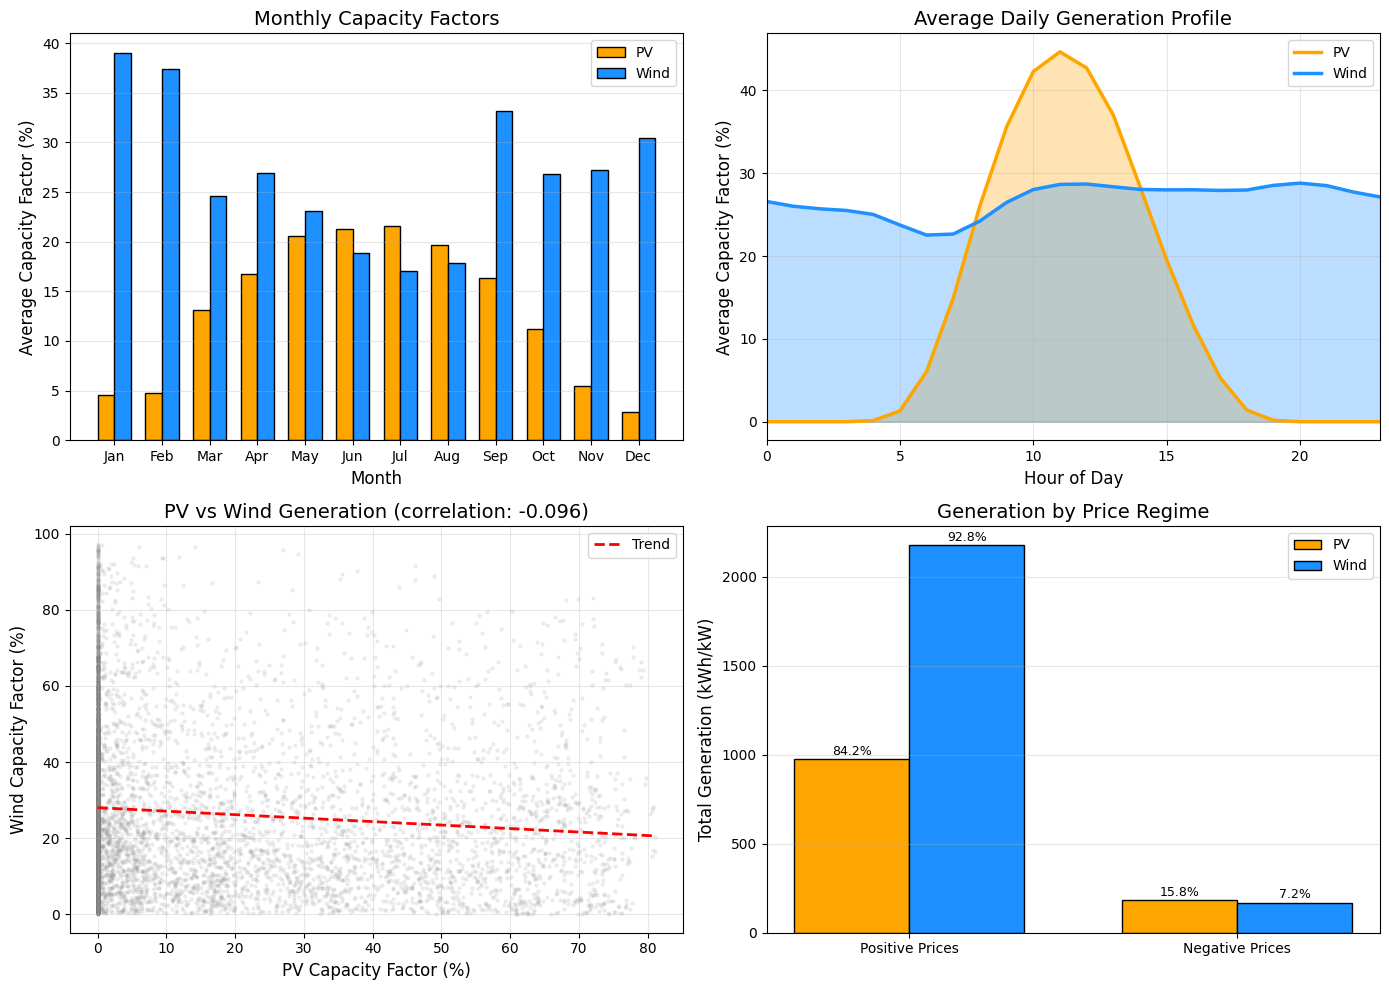

In [36]:
# Visualize generation profiles and their relationship
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Monthly capacity factors
df_monthly = df.copy()
df_monthly["month"] = df["timestamp"].dt.month
monthly_cf = df_monthly.groupby("month")[["pv_per_kw", "wind_per_kw"]].mean()

ax1 = axes[0, 0]
x = np.arange(1, 13)
width = 0.35
ax1.bar(x - width/2, monthly_cf["pv_per_kw"] * 100, width, label="PV", color=pv_color, edgecolor="black")
ax1.bar(x + width/2, monthly_cf["wind_per_kw"] * 100, width, label="Wind", color=wind_color, edgecolor="black")
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Average Capacity Factor (%)", fontsize=12)
ax1.set_title("Monthly Capacity Factors", fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# 2. Hourly profiles (average by hour of day)
df_hourly = df.copy()
df_hourly["hour"] = df["timestamp"].dt.hour
hourly_profile = df_hourly.groupby("hour")[["pv_per_kw", "wind_per_kw"]].mean()

ax2 = axes[0, 1]
ax2.plot(hourly_profile.index, hourly_profile["pv_per_kw"] * 100, "-", 
         label="PV", color=pv_color, linewidth=2.5)
ax2.plot(hourly_profile.index, hourly_profile["wind_per_kw"] * 100, "-", 
         label="Wind", color=wind_color, linewidth=2.5)
ax2.fill_between(hourly_profile.index, hourly_profile["pv_per_kw"] * 100, alpha=0.3, color=pv_color)
ax2.fill_between(hourly_profile.index, hourly_profile["wind_per_kw"] * 100, alpha=0.3, color=wind_color)
ax2.set_xlabel("Hour of Day", fontsize=12)
ax2.set_ylabel("Average Capacity Factor (%)", fontsize=12)
ax2.set_title("Average Daily Generation Profile", fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 23)

# 3. Scatter plot: PV vs Wind generation (correlation)
ax3 = axes[1, 0]
ax3.scatter(df["pv_per_kw"] * 100, df["wind_per_kw"] * 100, alpha=0.1, s=5, c="gray")
ax3.set_xlabel("PV Capacity Factor (%)", fontsize=12)
ax3.set_ylabel("Wind Capacity Factor (%)", fontsize=12)
ax3.set_title(f"PV vs Wind Generation (correlation: {correlation:.3f})", fontsize=14)
ax3.grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(df["pv_per_kw"], df["wind_per_kw"], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df["pv_per_kw"].max(), 100)
ax3.plot(x_line * 100, p(x_line) * 100, "r--", linewidth=2, label="Trend")
ax3.legend()

# 4. Generation during negative vs positive prices
ax4 = axes[1, 1]
positive_prices = df["price_eur_per_mwh"] >= 0
categories = ["Positive Prices", "Negative Prices"]
pv_values = [
    df.loc[positive_prices, "pv_per_kw"].sum(),
    df.loc[~positive_prices, "pv_per_kw"].sum()
]
wind_values = [
    df.loc[positive_prices, "wind_per_kw"].sum(),
    df.loc[~positive_prices, "wind_per_kw"].sum()
]

x = np.arange(len(categories))
width = 0.35
bars1 = ax4.bar(x - width/2, pv_values, width, label="PV", color=pv_color, edgecolor="black")
bars2 = ax4.bar(x + width/2, wind_values, width, label="Wind", color=wind_color, edgecolor="black")
ax4.set_ylabel("Total Generation (kWh/kW)", fontsize=12)
ax4.set_title("Generation by Price Regime", fontsize=14)
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.legend()
ax4.grid(True, alpha=0.3, axis="y")

# Add percentage labels
for bar, val, total in zip(bars1, pv_values, [df["pv_per_kw"].sum()]*2):
    ax4.annotate(f"{val/total*100:.1f}%", xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
for bar, val, total in zip(bars2, wind_values, [df["wind_per_kw"].sum()]*2):
    ax4.annotate(f"{val/total*100:.1f}%", xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(project_root / "figures" / "generation_profile_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
